POLYNOMIAL REGRESSION — ADVERTISING SALES PREDICTOR V1

Upload your Advertising CSV dataset:


Saving advertising.csv to advertising (2).csv

Dataset loaded successfully!
Dataset shape: (200, 4)

First 5 rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9



Required columns found successfully.

Missing values:


,0
TV,0
Radio,0
Newspaper,0
Sales,0



Duplicate rows: 0

Dataset statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000



Dataset after basic cleaning:
Rows: 200
Columns: 4

Features:
TV, Radio, Newspaper

Target:
Sales

Train-Test Split:
Training samples: 160
Testing samples: 40

Model trained successfully!
Model: Polynomial Regression
Polynomial Degree: 2

Sample Predictions:


,Actual Sales,Predicted Sales
0,16.9,17.562438
1,22.4,21.962857
2,21.4,22.075805
3,7.3,7.349163
4,24.7,23.236844
5,12.6,12.371095
6,22.3,22.128725
7,8.4,8.769049
8,16.5,17.014926
9,16.1,16.914806



MODEL PERFORMANCE
R² Score : 0.9533
MAE      : 0.9034
RMSE     : 1.2011

What these metrics mean:
R²  → How well the model explains variation in Sales.
MAE → Average size of the prediction error.
RMSE → Error measure that gives more weight to larger errors.


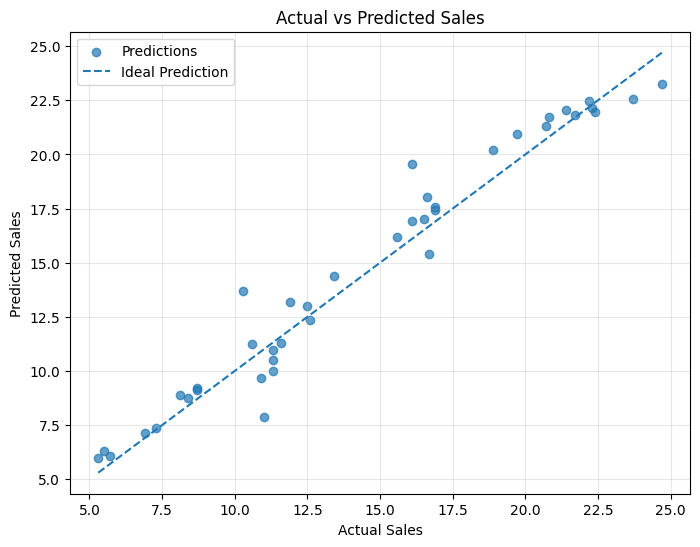


Graph explanation:
Each dot represents one test observation.
X-axis = actual Sales.
Y-axis = predicted Sales.
Points closer to the diagonal line represent more accurate predictions.


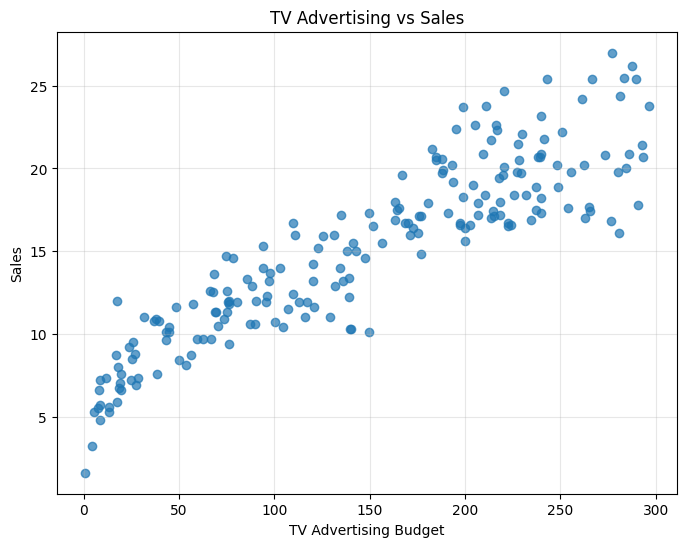

TV vs Sales:
Each point represents an observation from the dataset.
The graph helps us visually understand the relationship between TV advertising and Sales.


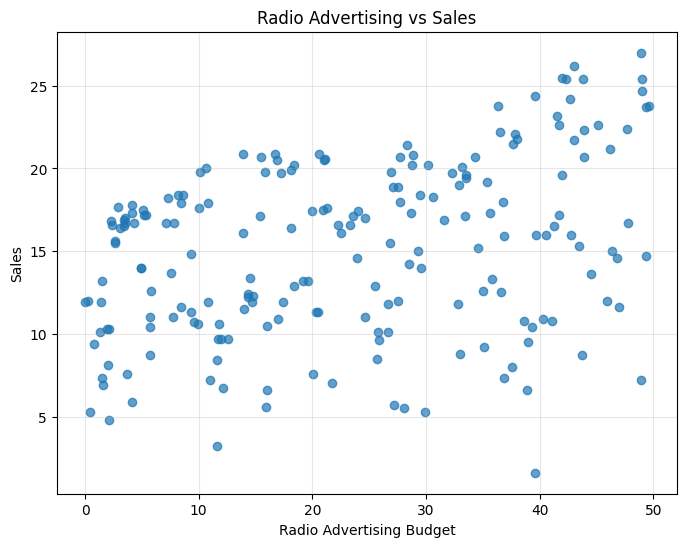

Radio vs Sales:
The graph shows how Sales vary with different Radio advertising budgets.


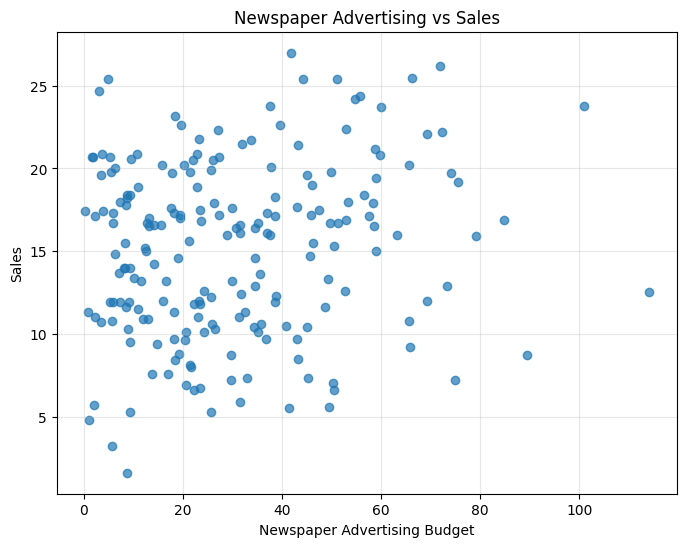

Newspaper vs Sales:
The graph shows how Sales vary with different Newspaper advertising budgets.

TRY YOUR OWN ADVERTISING BUDGET

Your Advertising Budget:
TV        : 150
Radio     : 25
Newspaper : 20

Predicted Sales: 15.88

COMPARE DIFFERENT ADVERTISING BUDGETS


,TV,Radio,Newspaper,Predicted Sales
0,50,10,5,8.725880
1,100,20,10,12.487919
2,150,25,20,15.879219
3,200,30,20,19.009384
4,250,40,25,22.825587



Polynomial features created by Degree 2:
['TV', 'Radio', 'Newspaper', 'TV^2', 'TV Radio', 'TV Newspaper', 'Radio^2', 'Radio Newspaper', 'Newspaper^2']

Simple explanation:
Polynomial Regression creates additional terms such as:
TV², Radio², Newspaper² and interaction terms.
These allow the model to capture curved and more complex relationships.

Model saved successfully:
polynomial_regression_model.pkl

Saved model verification:
Prediction from original model: 15.8792
Prediction from saved model   : 15.8792
✓ Saved model verified successfully!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


FINAL MODEL SUMMARY

Model              : Polynomial Regression
Polynomial Degree  : 2
Features           : TV, Radio, Newspaper
Target             : Sales

R² Score           : 0.9533
MAE                : 0.9034
RMSE               : 1.2011

Workflow:
Advertising Data
      ↓
Data Preparation
      ↓
Train-Test Split
      ↓
Polynomial Features
      ↓
Polynomial Regression
      ↓
Prediction
      ↓
Evaluation
      ↓
New Advertising Budget
      ↓
Predicted Sales

VERSION 1 COMPLETE


In [3]:
# ============================================================
# POLYNOMIAL REGRESSION — ADVERTISING SALES PREDICTOR V1
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("=" * 60)
print("POLYNOMIAL REGRESSION — ADVERTISING SALES PREDICTOR V1")
print("=" * 60)


# -----------------------------
# 2. UPLOAD AND LOAD DATASET
# -----------------------------
print("\nUpload your Advertising CSV dataset:")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


# -----------------------------
# 3. BASIC DATA CHECK
# -----------------------------
required_columns = ["TV", "Radio", "Newspaper", "Sales"]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"Required columns are missing from the dataset: {missing_columns}"
    )

print("\nRequired columns found successfully.")

print("\nMissing values:")
display(df[required_columns].isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset statistics:")
display(df[required_columns].describe())


# -----------------------------
# 4. CLEAN DATA
# -----------------------------
df = df[required_columns].copy()

# Remove rows containing missing values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

print("\nDataset after basic cleaning:")
print("Rows:", len(df))
print("Columns:", len(df.columns))


# -----------------------------
# 5. DEFINE FEATURES AND TARGET
# -----------------------------
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

print("\nFeatures:")
print("TV, Radio, Newspaper")

print("\nTarget:")
print("Sales")


# -----------------------------
# 6. TRAIN-TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain-Test Split:")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# -----------------------------
# 7. CREATE POLYNOMIAL REGRESSION MODEL
# -----------------------------
degree = 2

model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=degree,
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

# Train model
model.fit(X_train, y_train)

print("\nModel trained successfully!")
print("Model: Polynomial Regression")
print("Polynomial Degree:", degree)


# -----------------------------
# 8. TEST DATA PREDICTIONS
# -----------------------------
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

print("\nSample Predictions:")
display(results.head(10))


# -----------------------------
# 9. MODEL EVALUATION
# -----------------------------
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

print("\nWhat these metrics mean:")
print("R²  → How well the model explains variation in Sales.")
print("MAE → Average size of the prediction error.")
print("RMSE → Error measure that gives more weight to larger errors.")


# -----------------------------
# 10. ACTUAL VS PREDICTED GRAPH
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    label="Predictions"
)

# Ideal prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Ideal Prediction"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("\nGraph explanation:")
print("Each dot represents one test observation.")
print("X-axis = actual Sales.")
print("Y-axis = predicted Sales.")
print("Points closer to the diagonal line represent more accurate predictions.")


# -----------------------------
# 11. TV VS SALES
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    df["TV"],
    df["Sales"],
    alpha=0.7
)

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.grid(alpha=0.3)
plt.show()

print("TV vs Sales:")
print("Each point represents an observation from the dataset.")
print("The graph helps us visually understand the relationship between TV advertising and Sales.")


# -----------------------------
# 12. RADIO VS SALES
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Radio"],
    df["Sales"],
    alpha=0.7
)

plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.title("Radio Advertising vs Sales")
plt.grid(alpha=0.3)
plt.show()

print("Radio vs Sales:")
print("The graph shows how Sales vary with different Radio advertising budgets.")


# -----------------------------
# 13. NEWSPAPER VS SALES
# -----------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    df["Newspaper"],
    df["Sales"],
    alpha=0.7
)

plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.title("Newspaper Advertising vs Sales")
plt.grid(alpha=0.3)
plt.show()

print("Newspaper vs Sales:")
print("The graph shows how Sales vary with different Newspaper advertising budgets.")


# -----------------------------
# 14. TRY YOUR OWN VALUES
# -----------------------------
print("\n" + "=" * 60)
print("TRY YOUR OWN ADVERTISING BUDGET")
print("=" * 60)

TV_budget = 150
Radio_budget = 25
Newspaper_budget = 20

new_input = pd.DataFrame({
    "TV": [TV_budget],
    "Radio": [Radio_budget],
    "Newspaper": [Newspaper_budget]
})

predicted_sales = model.predict(new_input)[0]

print("\nYour Advertising Budget:")
print(f"TV        : {TV_budget}")
print(f"Radio     : {Radio_budget}")
print(f"Newspaper : {Newspaper_budget}")

print(f"\nPredicted Sales: {predicted_sales:.2f}")


# -----------------------------
# 15. TRY MULTIPLE SCENARIOS
# -----------------------------
print("\n" + "=" * 60)
print("COMPARE DIFFERENT ADVERTISING BUDGETS")
print("=" * 60)

scenarios = pd.DataFrame({
    "TV": [50, 100, 150, 200, 250],
    "Radio": [10, 20, 25, 30, 40],
    "Newspaper": [5, 10, 20, 20, 25]
})

scenarios["Predicted Sales"] = model.predict(
    scenarios[["TV", "Radio", "Newspaper"]]
)

display(scenarios)


# -----------------------------
# 16. SHOW POLYNOMIAL FEATURES
# -----------------------------
poly = model.named_steps["polynomial_features"]

feature_names = poly.get_feature_names_out(
    ["TV", "Radio", "Newspaper"]
)

print("\nPolynomial features created by Degree 2:")
print(feature_names.tolist())

print("\nSimple explanation:")
print("Polynomial Regression creates additional terms such as:")
print("TV², Radio², Newspaper² and interaction terms.")
print("These allow the model to capture curved and more complex relationships.")


# -----------------------------
# 17. SAVE COMPLETE MODEL PIPELINE
# -----------------------------
model_filename = "polynomial_regression_model.pkl"

joblib.dump(model, model_filename)

print("\nModel saved successfully:")
print(model_filename)


# -----------------------------
# 18. VERIFY SAVED MODEL
# -----------------------------
loaded_model = joblib.load(model_filename)

verification_prediction = loaded_model.predict(new_input)[0]

print("\nSaved model verification:")
print(f"Prediction from original model: {predicted_sales:.4f}")
print(f"Prediction from saved model   : {verification_prediction:.4f}")

if np.isclose(predicted_sales, verification_prediction):
    print("✓ Saved model verified successfully!")
else:
    print("⚠ Model verification failed.")


# -----------------------------
# 19. DOWNLOAD MODEL
# -----------------------------
print("\nDownloading trained model...")

files.download(model_filename)


# -----------------------------
# 20. FINAL SUMMARY
# -----------------------------
print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print(f"""
Model              : Polynomial Regression
Polynomial Degree  : {degree}
Features           : TV, Radio, Newspaper
Target             : Sales

R² Score           : {r2:.4f}
MAE                : {mae:.4f}
RMSE               : {rmse:.4f}

Workflow:
Advertising Data
      ↓
Data Preparation
      ↓
Train-Test Split
      ↓
Polynomial Features
      ↓
Polynomial Regression
      ↓
Prediction
      ↓
Evaluation
      ↓
New Advertising Budget
      ↓
Predicted Sales
""")

print("=" * 60)
print("VERSION 1 COMPLETE")
print("=" * 60)